In [2]:
import scipy.io
import numpy as np

# Load the dataset
mat = scipy.io.loadmat('data/processed/WildPPG.mat')

# See what keys are inside
print("Keys in the file:")
for key in mat.keys():
    if not key.startswith('_'):
        print(f"  {key}  →  {mat[key].shape}")

Keys in the file:
  data_bpm_values  →  (16, 1)
  data_altitude_values  →  (16, 1)
  data_ppg_chest  →  (16, 1)
  data_ppg_head  →  (16, 1)
  data_ppg_ankle  →  (16, 1)
  data_ppg_wrist  →  (16, 1)
  data_temp_chest  →  (16, 1)
  data_temp_head  →  (16, 1)
  data_temp_ankle  →  (16, 1)
  data_temp_wrist  →  (16, 1)
  data_imu_chest  →  (16, 1)
  data_imu_head  →  (16, 1)
  data_imu_ankle  →  (16, 1)
  data_imu_wrist  →  (16, 1)


In [3]:
ppg_wrist = mat['data_ppg_wrist']   # shape (16, 1)
bpm       = mat['data_bpm_values']  # shape (16, 1)

# Get subject 0's data
subject0_ppg = ppg_wrist[0, 0]
subject0_bpm = bpm[0, 0]

print("Subject 0 PPG wrist shape:", subject0_ppg.shape)
print("Subject 0 BPM shape:      ", subject0_bpm.shape)
print()
print("PPG value range:", subject0_ppg.min(), "to", subject0_ppg.max())
print("BPM value range:", subject0_bpm.min(), "to", subject0_bpm.max())

Subject 0 PPG wrist shape: (5994, 200)
Subject 0 BPM shape:       (5994, 1)

PPG value range: nan to nan
BPM value range: 57.1307120085016 to 138.3783783783784


In [4]:
# Clean out the NaN windows
ppg_raw = subject0_ppg  # (5994, 200)
bpm_raw = subject0_bpm.flatten()  # (5994,)

# Find windows where PPG has no NaN and BPM is valid
mask = (~np.isnan(ppg_raw).any(axis=1)) & (~np.isnan(bpm_raw)) & (bpm_raw >= 30)

ppg_clean = ppg_raw[mask]
bpm_clean = bpm_raw[mask]

print(f"Total windows    : {len(ppg_raw)}")
print(f"Valid windows    : {mask.sum()}")
print(f"Removed (NaN)    : {(~mask).sum()}")
print()
print(f"Clean PPG shape  : {ppg_clean.shape}")
print(f"BPM range        : {bpm_clean.min():.1f} to {bpm_clean.max():.1f} bpm")
print(f"BPM mean         : {bpm_clean.mean():.1f} bpm")

Total windows    : 5994
Valid windows    : 5981
Removed (NaN)    : 13

Clean PPG shape  : (5981, 200)
BPM range        : 57.1 to 138.4 bpm
BPM mean         : 75.9 bpm


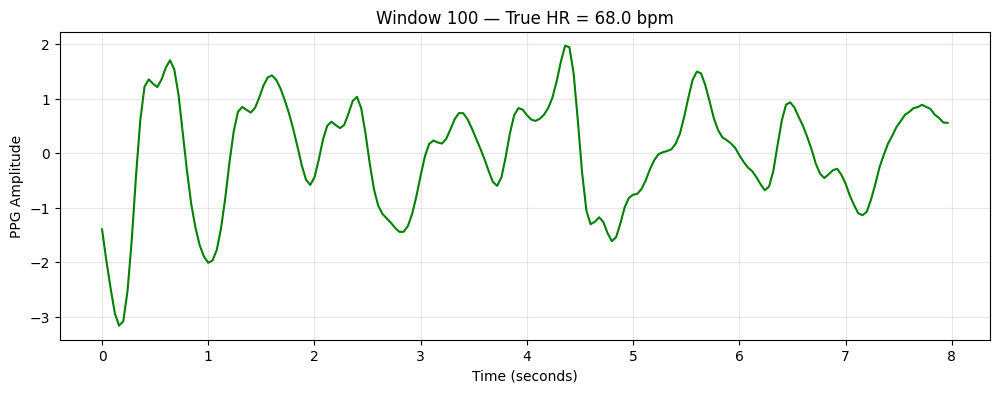

This is 8 seconds of green light PPG from the wrist
The ECG says the true heart rate during this window is 68.0 bpm
That means we should see roughly 9.1 heartbeat pulses in the plot


In [5]:
import matplotlib.pyplot as plt

# Pick one window and look at it
window_idx = 100
ppg_window = ppg_clean[window_idx]   # 200 samples = 8 seconds
true_hr    = bpm_clean[window_idx]

# Time axis: 200 samples at 25 Hz = 8 seconds
time = np.arange(200) / 25.0

plt.figure(figsize=(12, 4))
plt.plot(time, ppg_window, color='green', linewidth=1.5)
plt.xlabel('Time (seconds)')
plt.ylabel('PPG Amplitude')
plt.title(f'Window {window_idx} — True HR = {true_hr:.1f} bpm')
plt.grid(True, alpha=0.3)
plt.show()

print(f"This is 8 seconds of green light PPG from the wrist")
print(f"The ECG says the true heart rate during this window is {true_hr:.1f} bpm")
print(f"That means we should see roughly {true_hr/60*8:.1f} heartbeat pulses in the plot")

c:\Users\hrana\anaconda3\envs\ml_env_fixed\Lib\site-packages\numpy\_core\_methods.py:171: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


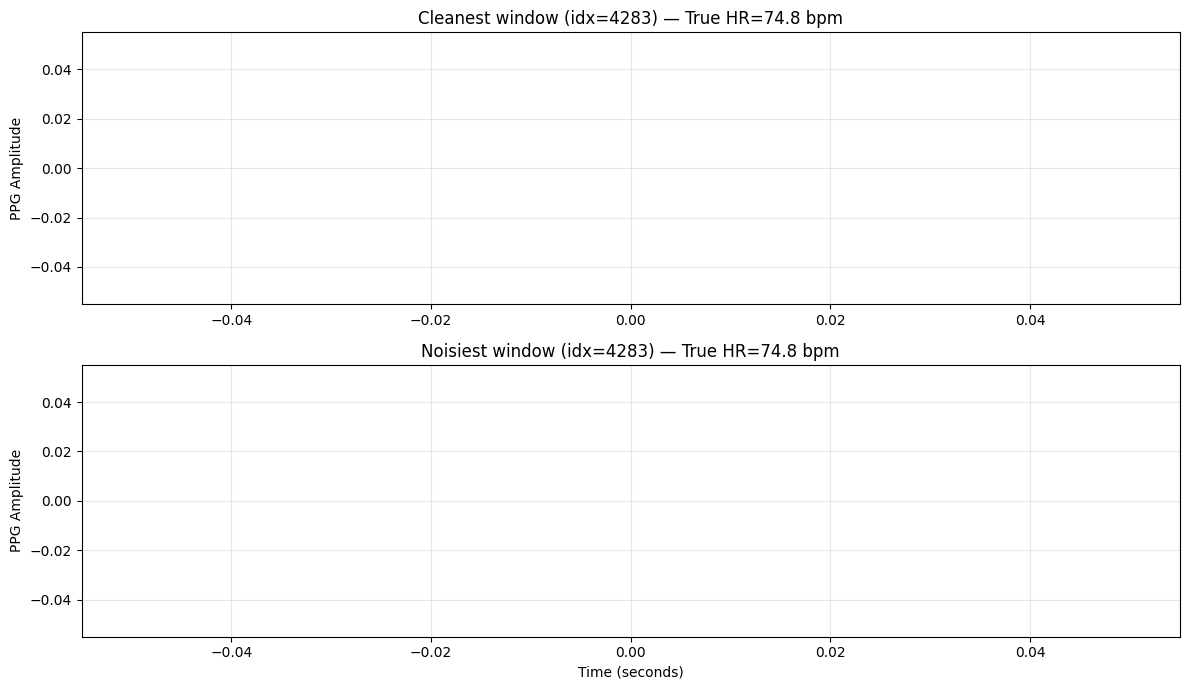

In [6]:
window_stds = ppg_clean.std(axis=1)

cleanest_idx = window_stds.argmin()
noisiest_idx = window_stds.argmax()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
time = np.arange(200) / 25.0

axes[0].plot(time, ppg_clean[cleanest_idx], color='green', linewidth=1.5)
axes[0].set_title(f'Cleanest window (idx={cleanest_idx}) — True HR={bpm_clean[cleanest_idx]:.1f} bpm')
axes[0].set_ylabel('PPG Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, ppg_clean[noisiest_idx], color='red', linewidth=1.5)
axes[1].set_title(f'Noisiest window (idx={noisiest_idx}) — True HR={bpm_clean[noisiest_idx]:.1f} bpm')
axes[1].set_ylabel('PPG Amplitude')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Check what the "cleanest" window actually contains
print("Cleanest window values:", ppg_clean[cleanest_idx][:20])
print("Std of cleanest:", window_stds[cleanest_idx])
print()

print("Std statistics:")
print(f"  min: {window_stds.min():.4f}")
print(f"  max: {window_stds.max():.4f}")
print(f"  mean: {window_stds.mean():.4f}")
print()


print(f"Windows with std < 0.01: {(window_stds < 0.01).sum()}")
print(f"Windows with std > 0.1:  {(window_stds > 0.1).sum()}")

Cleanest window values: [inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf]
Std of cleanest: nan

Std statistics:
  min: nan
  max: nan
  mean: nan

Windows with std < 0.01: 0
Windows with std > 0.1:  5885


In [8]:
# Better cleaning — remove NaN, inf, and zero-only windows
mask = (
    ~np.isnan(ppg_raw).any(axis=1) &   # no NaN
    ~np.isinf(ppg_raw).any(axis=1) &   # no infinity
    (bpm_raw >= 30) &                   # valid HR
    ~np.isnan(bpm_raw)
)

ppg_clean = ppg_raw[mask]
bpm_clean = bpm_raw[mask]

print(f"Valid windows after full cleaning: {len(ppg_clean)}")
print(f"Sample values from window 100: {ppg_clean[100][:5]}")
print(f"Std of window 100: {ppg_clean[100].std():.4f}")

Valid windows after full cleaning: 5885
Sample values from window 100: [-1.39544204 -1.96319422 -2.46813031 -2.93301144 -3.16361899]
Std of window 100: 1.0000


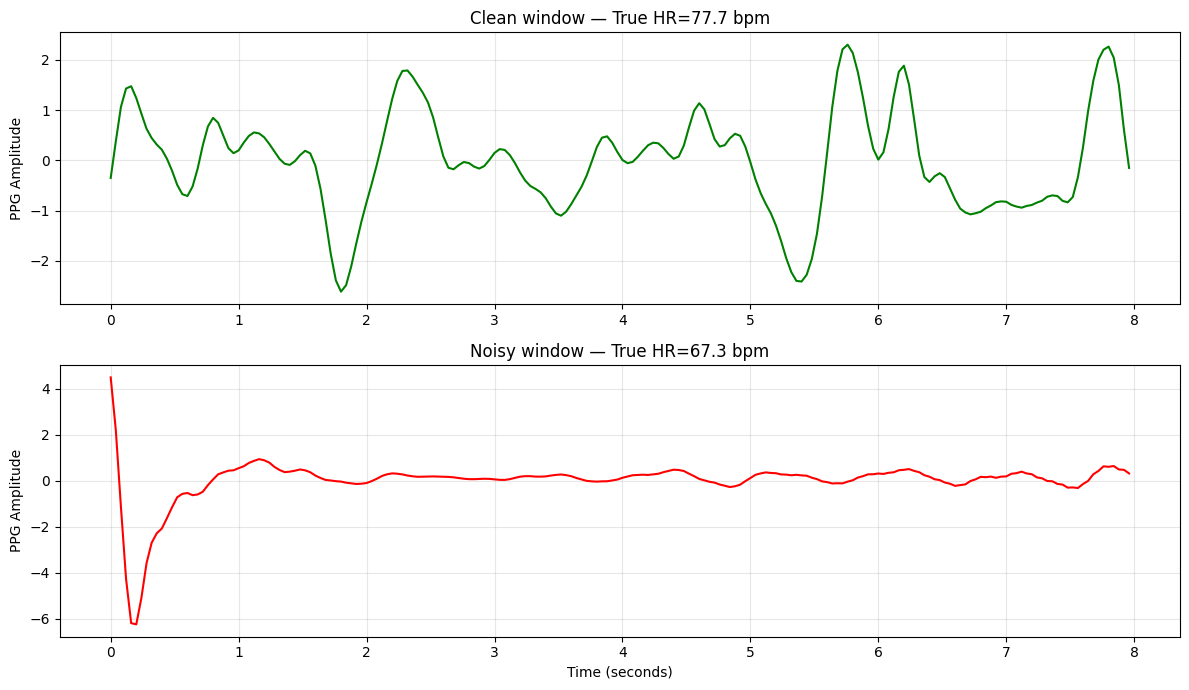

In [9]:
# Since data is pre-normalized, use peak-to-peak range as noise measure
# Clean PPG = smooth regular wave = moderate range
# Noisy PPG = wild swings = very large range

ppg_ranges = np.ptp(ppg_clean, axis=1)  # max - min per window

# Sort by range
sorted_idx = np.argsort(ppg_ranges)

cleanest_idx = sorted_idx[len(sorted_idx)//4]   # 25th percentile
noisiest_idx = sorted_idx[-10]                   # near the top

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
time = np.arange(200) / 25.0

axes[0].plot(time, ppg_clean[cleanest_idx], color='green', linewidth=1.5)
axes[0].set_title(f'Clean window — True HR={bpm_clean[cleanest_idx]:.1f} bpm')
axes[0].set_ylabel('PPG Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, ppg_clean[noisiest_idx], color='red', linewidth=1.5)
axes[1].set_title(f'Noisy window — True HR={bpm_clean[noisiest_idx]:.1f} bpm')
axes[1].set_ylabel('PPG Amplitude')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

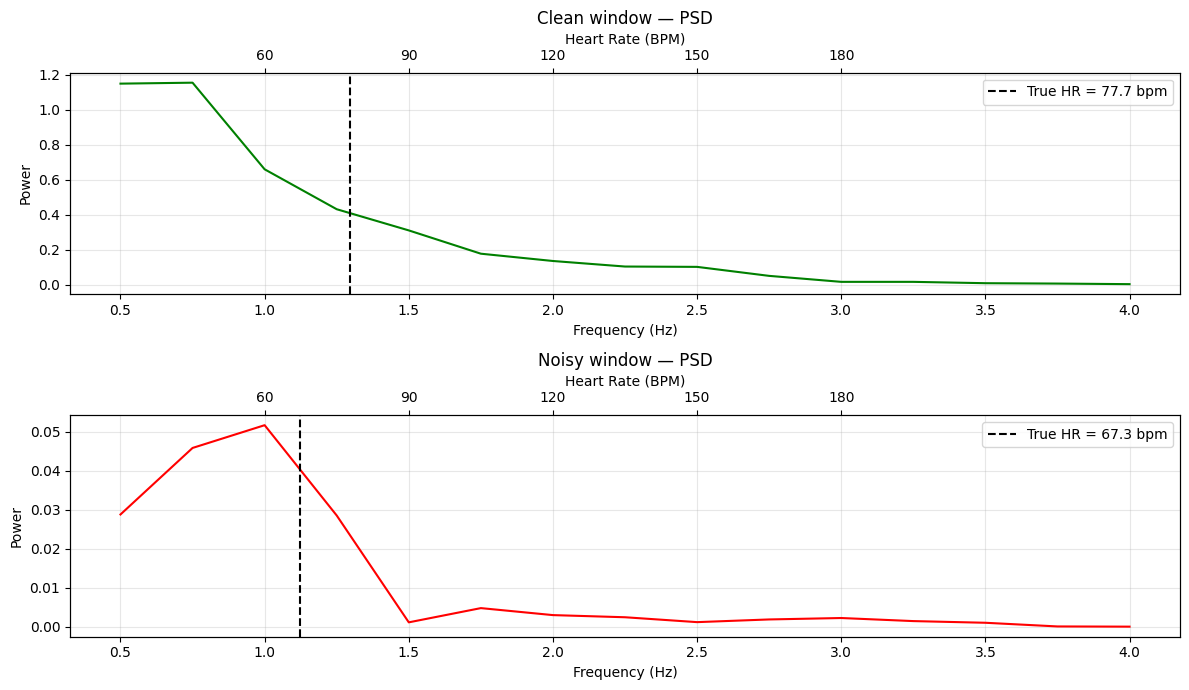

In [10]:
from scipy.signal import welch

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

for ax, idx, color, label in [
    (axes[0], cleanest_idx, 'green', 'Clean'),
    (axes[1], noisiest_idx, 'red',   'Noisy'),
]:
    signal = ppg_clean[idx]
    freqs, psd = welch(signal, fs=25, nperseg=100)

    # Only show 0.5 to 4 Hz (cardiac band)
    mask = (freqs >= 0.5) & (freqs <= 4.0)
    
    ax.plot(freqs[mask], psd[mask], color=color, linewidth=1.5)
    ax.set_ylabel('Power')
    ax.set_xlabel('Frequency (Hz)')
    
    # Add BPM labels on top axis
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([1, 1.5, 2, 2.5, 3])
    ax2.set_xticklabels(['60', '90', '120', '150', '180'])
    ax2.set_xlabel('Heart Rate (BPM)')
    
    true_freq = bpm_clean[idx] / 60
    ax.axvline(true_freq, color='black', linestyle='--', linewidth=1.5,
               label=f'True HR = {bpm_clean[idx]:.1f} bpm')
    ax.set_title(f'{label} window — PSD')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

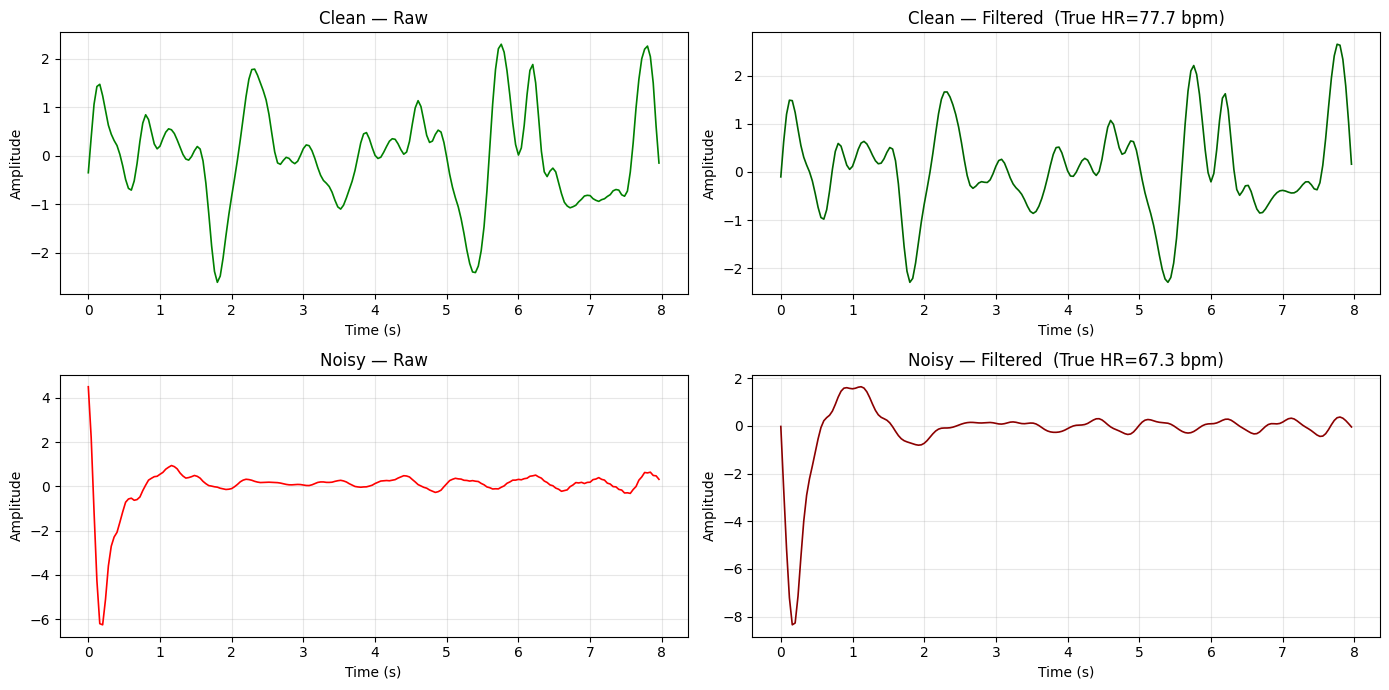

In [11]:
from scipy.signal import butter, sosfiltfilt

def bandpass(signal, low=0.5, high=4.0, fs=25):
    sos = butter(4, [low/(fs/2), high/(fs/2)], btype='band', output='sos')
    return sosfiltfilt(sos, signal)

# Filter both windows
clean_filtered = bandpass(ppg_clean[cleanest_idx])
noisy_filtered = bandpass(ppg_clean[noisiest_idx])

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
time = np.arange(200) / 25.0

# Raw vs filtered waveforms
axes[0,0].plot(time, ppg_clean[cleanest_idx], color='green', linewidth=1.2)
axes[0,0].set_title('Clean — Raw')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(time, clean_filtered, color='darkgreen', linewidth=1.2)
axes[0,1].set_title(f'Clean — Filtered  (True HR={bpm_clean[cleanest_idx]:.1f} bpm)')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(time, ppg_clean[noisiest_idx], color='red', linewidth=1.2)
axes[1,0].set_title('Noisy — Raw')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(time, noisy_filtered, color='darkred', linewidth=1.2)
axes[1,1].set_title(f'Noisy — Filtered  (True HR={bpm_clean[noisiest_idx]:.1f} bpm)')
axes[1,1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [12]:
# Let's build a simple 1D CNN from scratch and understand each part
import torch
import torch.nn as nn

x_example = torch.tensor(ppg_clean[100], dtype=torch.float32)
x_example = x_example.unsqueeze(0).unsqueeze(0)  # → (1, 1, 200)

print("Input shape:", x_example.shape)
print("  batch=1, channels=1, time=200")
print()
print("The network sees 200 numbers and must output 1 number — the HR in bpm")
print(f"For this window the correct answer is: {bpm_clean[100]:.1f} bpm")

Input shape: torch.Size([1, 1, 200])
  batch=1, channels=1, time=200

The network sees 200 numbers and must output 1 number — the HR in bpm
For this window the correct answer is: 68.0 bpm


In [13]:
# Build a simple CNN step by step
# Each Conv1d layer slides a small filter across the 200 time steps
# and learns to detect patterns (like a heartbeat shape)

model = nn.Sequential(
    # Layer 1: detect local patterns (like individual pulse peaks)
    # kernel_size=7 means it looks at 7 samples at a time (0.28 seconds)
    nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),   # 200 → 100

    # Layer 2: detect larger patterns (like one full heartbeat cycle)
    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),   # 100 → 50

    # Layer 3: detect even larger patterns (multiple beats = rhythm)
    nn.Conv1d(in_channels=32, out_channels=64, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.AdaptiveAvgPool1d(1),       # 50 → 1 (global average)

    # Flatten and predict HR
    nn.Flatten(),
    nn.Linear(64, 1)               # 64 features → 1 HR value
)

# Pass our example through and watch the shape change
print("Tracing the shape through the network:\n")
x = x_example
print(f"  Input:          {x.shape}")

layers = list(model.children())
for layer in layers:
    x = layer(x)
    print(f"  After {str(layer)[:40]:40s} → {x.shape}")

print(f"\n  Final output: {x.item():.2f} bpm  (untrained, so random)")
print(f"  True answer:  {bpm_clean[100]:.1f} bpm")

Tracing the shape through the network:

  Input:          torch.Size([1, 1, 200])
  After Conv1d(1, 16, kernel_size=(7,), stride=( → torch.Size([1, 16, 200])
  After ReLU()                                   → torch.Size([1, 16, 200])
  After MaxPool1d(kernel_size=2, stride=2, paddi → torch.Size([1, 16, 100])
  After Conv1d(16, 32, kernel_size=(7,), stride= → torch.Size([1, 32, 100])
  After ReLU()                                   → torch.Size([1, 32, 100])
  After MaxPool1d(kernel_size=2, stride=2, paddi → torch.Size([1, 32, 50])
  After Conv1d(32, 64, kernel_size=(7,), stride= → torch.Size([1, 64, 50])
  After ReLU()                                   → torch.Size([1, 64, 50])
  After AdaptiveAvgPool1d(output_size=1)         → torch.Size([1, 64, 1])
  After Flatten(start_dim=1, end_dim=-1)         → torch.Size([1, 64])
  After Linear(in_features=64, out_features=1, b → torch.Size([1, 1])

  Final output: -0.05 bpm  (untrained, so random)
  True answer:  68.0 bpm


In [14]:
# Prepare all subjects' data for training
all_ppg, all_bpm = [], []

for i in range(16):
    ppg_i = mat['data_ppg_wrist'][i, 0]
    bpm_i = mat['data_bpm_values'][i, 0].flatten()
    
    mask = (
        ~np.isnan(ppg_i).any(axis=1) &
        ~np.isinf(ppg_i).any(axis=1) &
        (bpm_i >= 30) & ~np.isnan(bpm_i)
    )
    all_ppg.append(ppg_i[mask])
    all_bpm.append(bpm_i[mask])

# Stack everything
X = np.concatenate(all_ppg, axis=0).astype(np.float32)  # (N, 200)
y = np.concatenate(all_bpm, axis=0).astype(np.float32)  # (N,)

print(f"Total windows : {len(X)}")
print(f"HR range      : {y.min():.1f} – {y.max():.1f} bpm")
print(f"HR mean       : {y.mean():.1f} bpm")

Total windows : 94806
HR range      : 34.3 – 204.8 bpm
HR mean       : 78.1 bpm


In [15]:
# Split by subject — NOT randomly
# Train: subjects 0-12  (13 subjects)
# Test:  subjects 13-15 (3 subjects)

train_ppg, train_bpm = [], []
test_ppg,  test_bpm  = [], []

for i in range(16):
    ppg_i = mat['data_ppg_wrist'][i, 0]
    bpm_i = mat['data_bpm_values'][i, 0].flatten()
    
    mask = (
        ~np.isnan(ppg_i).any(axis=1) &
        ~np.isinf(ppg_i).any(axis=1) &
        (bpm_i >= 30) & ~np.isnan(bpm_i)
    )
    ppg_clean_i = ppg_i[mask].astype(np.float32)
    bpm_clean_i = bpm_i[mask].astype(np.float32)
    
    if i < 13:
        train_ppg.append(ppg_clean_i)
        train_bpm.append(bpm_clean_i)
    else:
        test_ppg.append(ppg_clean_i)
        test_bpm.append(bpm_clean_i)

X_train = np.concatenate(train_ppg)
y_train = np.concatenate(train_bpm)
X_test  = np.concatenate(test_ppg)
y_test  = np.concatenate(test_bpm)

print(f"Train: {len(X_train)} windows from subjects 0–12")
print(f"Test:  {len(X_test)}  windows from subjects 13–15")
print(f"\nTrain HR: {y_train.mean():.1f} bpm mean")
print(f"Test HR:  {y_test.mean():.1f} bpm mean")

Train: 78059 windows from subjects 0–12
Test:  16747  windows from subjects 13–15

Train HR: 75.9 bpm mean
Test HR:  88.4 bpm mean


In [16]:
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
# Shape: (N, 1, 200) — add channel dimension
X_train_t = torch.tensor(X_train).unsqueeze(1)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test).unsqueeze(1)
y_test_t  = torch.tensor(y_test)

# DataLoaders
train_ds     = TensorDataset(X_train_t, y_train_t)
test_ds      = TensorDataset(X_test_t,  y_test_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Setup training
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.HuberLoss(delta=5.0)

print(f"\nTraining on: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Train batches : 305
Test batches  : 66

Training on: cuda
Model parameters: 18,209


In [17]:
# Training loop — 30 epochs
train_losses = []
test_maes    = []

for epoch in range(1, 31):
    # ── Train ──
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        pred = model(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # ── Evaluate ──
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            pred = model(X_batch.to(device)).squeeze().cpu()
            all_preds.append(pred.numpy())
            all_true.append(y_batch.numpy())
    
    preds = np.concatenate(all_preds)
    true  = np.concatenate(all_true)
    mae   = np.mean(np.abs(preds - true))
    
    train_losses.append(epoch_loss / len(train_loader))
    test_maes.append(mae)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d}/30 | loss={train_losses[-1]:.3f} | test MAE={mae:.2f} bpm")

print(f"\nBest MAE: {min(test_maes):.2f} bpm at epoch {test_maes.index(min(test_maes))+1}")

Epoch   5/30 | loss=38.610 | test MAE=12.50 bpm
Epoch  10/30 | loss=36.680 | test MAE=13.21 bpm
Epoch  15/30 | loss=36.274 | test MAE=12.83 bpm
Epoch  20/30 | loss=35.906 | test MAE=12.33 bpm
Epoch  25/30 | loss=35.539 | test MAE=12.53 bpm
Epoch  30/30 | loss=35.207 | test MAE=11.74 bpm

Best MAE: 11.70 bpm at epoch 29


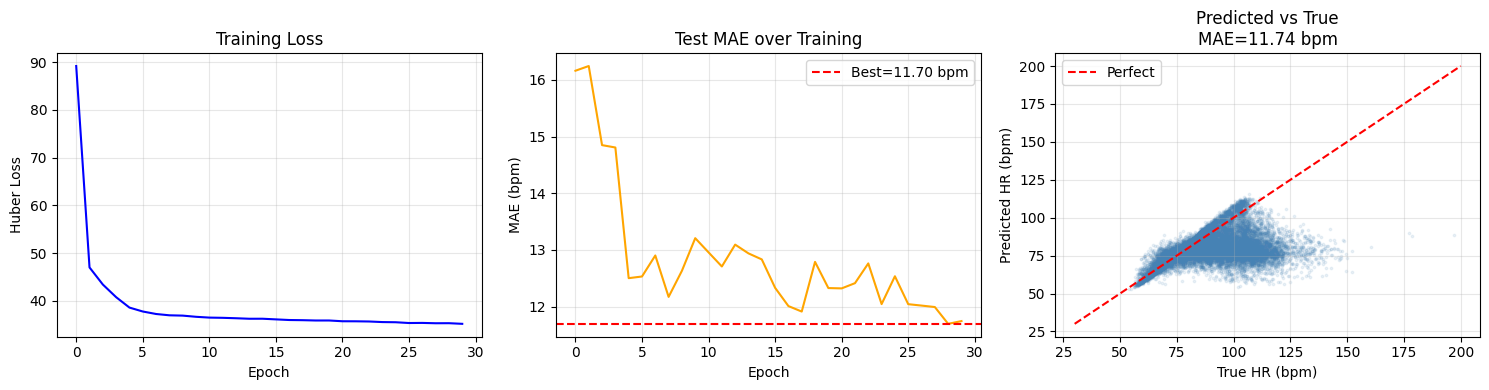

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Plot 1: Training curve ──
axes[0].plot(train_losses, color='blue', linewidth=1.5, label='Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_maes, color='orange', linewidth=1.5)
axes[1].axhline(min(test_maes), color='red', linestyle='--',
                label=f'Best={min(test_maes):.2f} bpm')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (bpm)')
axes[1].set_title('Test MAE over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Plot 2: Predicted vs True scatter ──
axes[2].scatter(true, preds, alpha=0.1, s=3, color='steelblue')
axes[2].plot([30, 200], [30, 200], 'r--', linewidth=1.5, label='Perfect')
axes[2].set_xlabel('True HR (bpm)')
axes[2].set_ylabel('Predicted HR (bpm)')
axes[2].set_title(f'Predicted vs True\nMAE={np.mean(np.abs(preds-true)):.2f} bpm')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Train for 100 more epochs (continuing from epoch 30)
for epoch in range(31, 131):
    # ── Train ──
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # ── Evaluate ──
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            pred = model(X_batch.to(device)).squeeze().cpu()
            all_preds.append(pred.numpy())
            all_true.append(y_batch.numpy())

    preds = np.concatenate(all_preds)
    true  = np.concatenate(all_true)
    mae   = np.mean(np.abs(preds - true))

    train_losses.append(epoch_loss / len(train_loader))
    test_maes.append(mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/130 | loss={train_losses[-1]:.3f} | test MAE={mae:.2f} bpm")

print(f"\nBest MAE: {min(test_maes):.2f} bpm at epoch {test_maes.index(min(test_maes))+1}")

Epoch  40/130 | loss=34.501 | test MAE=11.99 bpm
Epoch  50/130 | loss=33.836 | test MAE=12.04 bpm
Epoch  60/130 | loss=33.271 | test MAE=11.72 bpm
Epoch  70/130 | loss=33.031 | test MAE=10.61 bpm
Epoch  80/130 | loss=32.680 | test MAE=10.88 bpm
Epoch  90/130 | loss=32.432 | test MAE=10.97 bpm
Epoch 100/130 | loss=32.311 | test MAE=10.61 bpm
Epoch 110/130 | loss=32.135 | test MAE=11.00 bpm
Epoch 120/130 | loss=32.101 | test MAE=10.77 bpm
Epoch 130/130 | loss=31.841 | test MAE=10.92 bpm

Best MAE: 10.35 bpm at epoch 106


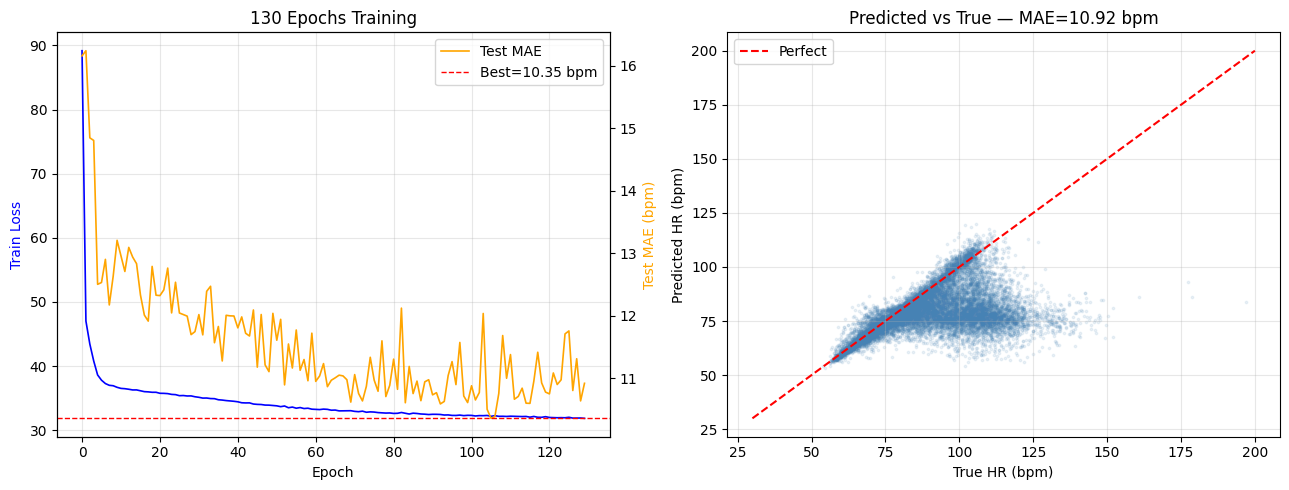

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Full training curve (all 130 epochs)
axes[0].plot(train_losses, color='blue', linewidth=1.2, label='Train loss')
ax_r = axes[0].twinx()
ax_r.plot(test_maes, color='orange', linewidth=1.2, label='Test MAE')
ax_r.axhline(min(test_maes), color='red', linestyle='--', linewidth=1,
             label=f'Best={min(test_maes):.2f} bpm')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss', color='blue')
ax_r.set_ylabel('Test MAE (bpm)', color='orange')
axes[0].set_title('130 Epochs Training')
ax_r.legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Scatter
axes[1].scatter(true, preds, alpha=0.1, s=3, color='steelblue')
axes[1].plot([30, 200], [30, 200], 'r--', linewidth=1.5, label='Perfect')
axes[1].set_xlabel('True HR (bpm)')
axes[1].set_ylabel('Predicted HR (bpm)')
axes[1].set_title(f'Predicted vs True — MAE={np.mean(np.abs(preds-true)):.2f} bpm')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

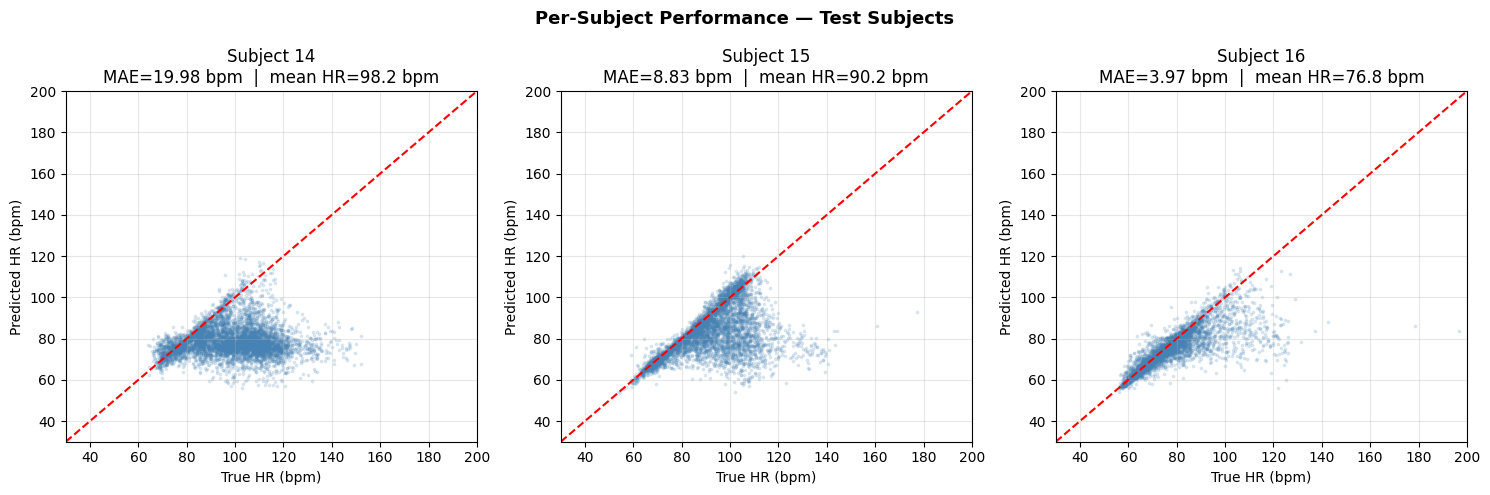

In [21]:
# Evaluate per subject on test subjects (13, 14, 15)
model.eval()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for plot_idx, subj_idx in enumerate([13, 14, 15]):
    ppg_i = mat['data_ppg_wrist'][subj_idx, 0]
    bpm_i = mat['data_bpm_values'][subj_idx, 0].flatten()
    
    mask = (
        ~np.isnan(ppg_i).any(axis=1) &
        ~np.isinf(ppg_i).any(axis=1) &
        (bpm_i >= 30) & ~np.isnan(bpm_i)
    )
    X_subj = torch.tensor(ppg_i[mask].astype(np.float32)).unsqueeze(1).to(device)
    y_subj = bpm_i[mask]
    
    with torch.no_grad():
        preds_subj = model(X_subj).squeeze().cpu().numpy()
    
    mae  = np.mean(np.abs(preds_subj - y_subj))
    
    axes[plot_idx].scatter(y_subj, preds_subj, alpha=0.15, s=3, color='steelblue')
    axes[plot_idx].plot([30, 200], [30, 200], 'r--', linewidth=1.5)
    axes[plot_idx].set_xlabel('True HR (bpm)')
    axes[plot_idx].set_ylabel('Predicted HR (bpm)')
    axes[plot_idx].set_title(f'Subject {subj_idx+1}\nMAE={mae:.2f} bpm  |  mean HR={y_subj.mean():.1f} bpm')
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].set_xlim(30, 200)
    axes[plot_idx].set_ylim(30, 200)

plt.suptitle('Per-Subject Performance — Test Subjects', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Check all the keys again and look at the other PPG fields
print("All keys in the .mat file:")
for key in mat.keys():
    if not key.startswith('_'):
        inner = mat[key][0, 0]
        print(f"  {key:25s} → inner shape: {inner.shape}")

All keys in the .mat file:
  data_bpm_values           → inner shape: (5994, 1)
  data_altitude_values      → inner shape: (5994, 1)
  data_ppg_chest            → inner shape: (5994, 200)
  data_ppg_head             → inner shape: (5994, 200)
  data_ppg_ankle            → inner shape: (5994, 200)
  data_ppg_wrist            → inner shape: (5994, 200)
  data_temp_chest           → inner shape: (5994, 1)
  data_temp_head            → inner shape: (5994, 1)
  data_temp_ankle           → inner shape: (5994, 1)
  data_temp_wrist           → inner shape: (5994, 1)
  data_imu_chest            → inner shape: (5994, 1)
  data_imu_head             → inner shape: (5994, 1)
  data_imu_ankle            → inner shape: (5994, 1)
  data_imu_wrist            → inner shape: (5994, 1)


In [23]:
# Check what IMU actually contains — is it a scalar or nested?
imu_raw = mat['data_imu_wrist'][0, 0]
print("IMU wrist shape:", imu_raw.shape)
print("IMU first value:", imu_raw[0])
print("IMU dtype:", imu_raw.dtype)
print()

# Also check one PPG site we haven't looked at
ankle = mat['data_ppg_ankle'][0, 0]
print("Ankle PPG shape:", ankle.shape)
print("Ankle sample values:", ankle[100, :5])
print()

# Compare wrist vs ankle for same window
wrist = mat['data_ppg_wrist'][0, 0]
print("Wrist sample values:", wrist[100, :5])

IMU wrist shape: (5994, 1)
IMU first value: [1.00437533]
IMU dtype: float64

Ankle PPG shape: (5994, 200)
Ankle sample values: [ 0.12446171  0.03162266 -0.09882876 -0.26076838 -0.4431624 ]

Wrist sample values: [-1.39544204 -1.96319422 -2.46813031 -2.93301144 -3.16361899]


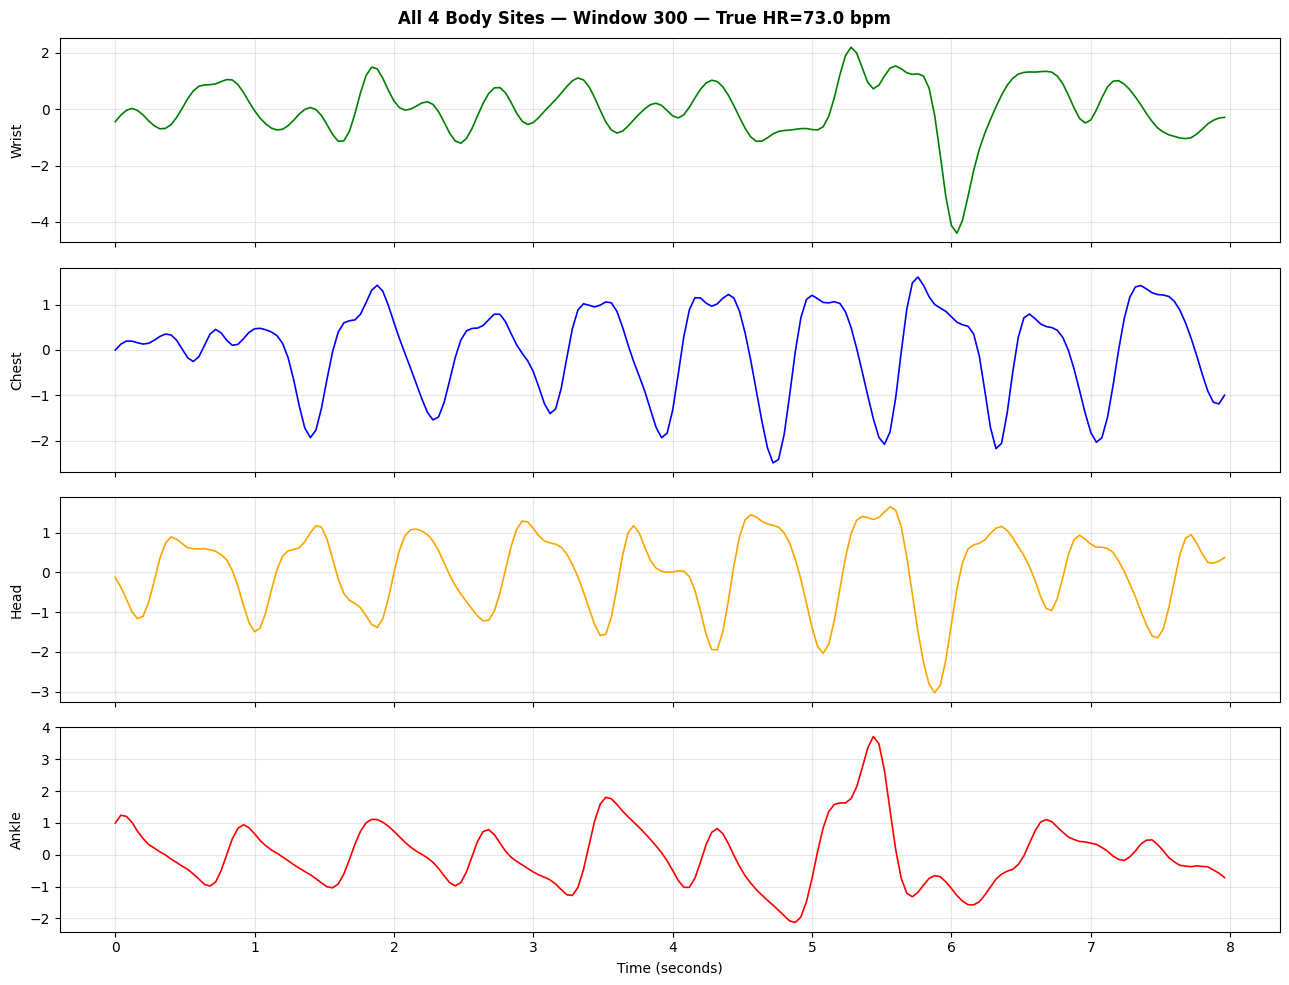

In [24]:
# Compare all 4 body sites for the same window
sites = ['data_ppg_wrist', 'data_ppg_chest', 'data_ppg_head', 'data_ppg_ankle']
colors = ['green', 'blue', 'orange', 'red']
labels = ['Wrist', 'Chest', 'Head', 'Ankle']

window_idx = 300
time = np.arange(200) / 25.0
true_hr = mat['data_bpm_values'][0, 0].flatten()[window_idx]

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

for ax, site, color, label in zip(axes, sites, colors, labels):
    signal = mat[site][0, 0][window_idx]
    
    # Skip if NaN or Inf
    if np.isnan(signal).any() or np.isinf(signal).any():
        ax.text(4, 0, 'corrupted window', ha='center', fontsize=12)
    else:
        ax.plot(time, signal, color=color, linewidth=1.2)
    
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle(f'All 4 Body Sites — Window {window_idx} — True HR={true_hr:.1f} bpm',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Load all 4 sites for all subjects
sites = ['data_ppg_wrist', 'data_ppg_chest', 'data_ppg_head', 'data_ppg_ankle']

def load_all_sites(mat, subject_idx):
    """Load 4-channel PPG for one subject. Returns (N, 4, 200) and (N,) BPM."""
    bpm_raw = mat['data_bpm_values'][subject_idx, 0].flatten()
    
    channels = []
    for site in sites:
        channels.append(mat[site][subject_idx, 0])  # (N, 200)
    
    # Stack → (N, 4, 200)
    X = np.stack(channels, axis=1).astype(np.float32)
    y = bpm_raw.astype(np.float32)
    
    # Clean: no NaN, no Inf, valid BPM
    mask = (
        ~np.isnan(X).any(axis=(1,2)) &
        ~np.isinf(X).any(axis=(1,2)) &
        (y >= 30) & ~np.isnan(y)
    )
    return X[mask], y[mask]

# Test on subject 0
X0, y0 = load_all_sites(mat, 0)
print(f"Subject 0: X={X0.shape}, y={y0.shape}")
print(f"Shape means: {X0.shape[0]} windows, {X0.shape[1]} sites, {X0.shape[2]} samples")

Subject 0: X=(5885, 4, 200), y=(5885,)
Shape means: 5885 windows, 4 sites, 200 samples


In [26]:
# Load all 16 subjects
train_X, train_y = [], []
test_X,  test_y  = [], []

for i in range(16):
    X_i, y_i = load_all_sites(mat, i)
    if i < 13:
        train_X.append(X_i)
        train_y.append(y_i)
    else:
        test_X.append(X_i)
        test_y.append(y_i)

X_train_4ch = np.concatenate(train_X)
y_train_4ch = np.concatenate(train_y)
X_test_4ch  = np.concatenate(test_X)
y_test_4ch  = np.concatenate(test_y)

print(f"Train: {X_train_4ch.shape}")
print(f"Test:  {X_test_4ch.shape}")

# PyTorch loaders
X_train_t = torch.tensor(X_train_4ch)
y_train_t = torch.tensor(y_train_4ch)
X_test_t  = torch.tensor(X_test_4ch)
y_test_t  = torch.tensor(y_test_4ch)

train_loader_4ch = DataLoader(TensorDataset(X_train_t, y_train_t),
                               batch_size=256, shuffle=True)
test_loader_4ch  = DataLoader(TensorDataset(X_test_t, y_test_t),
                               batch_size=256, shuffle=False)

print(f"\nTrain batches: {len(train_loader_4ch)}")
print(f"Test batches:  {len(test_loader_4ch)}")

Train: (78059, 4, 200)
Test:  (16747, 4, 200)

Train batches: 305
Test batches:  66


In [27]:
# Same CNN architecture, now takes 4 channels instead of 1
model_4ch = nn.Sequential(
    nn.Conv1d(in_channels=4, out_channels=16, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),       # 200 → 100

    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),       # 100 → 50

    nn.Conv1d(in_channels=32, out_channels=64, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.AdaptiveAvgPool1d(1),           # 50 → 1

    nn.Flatten(),
    nn.Linear(64, 1)
).to(device)

optimizer_4ch = torch.optim.Adam(model_4ch.parameters(), lr=1e-3)

print(f"Parameters: {sum(p.numel() for p in model_4ch.parameters()):,}")

# Quick shape check
x_test = torch.randn(1, 4, 200).to(device)
print(f"Input shape:  (1, 4, 200)")
print(f"Output shape: {model_4ch(x_test).shape}")

Parameters: 18,545
Input shape:  (1, 4, 200)
Output shape: torch.Size([1, 1])


In [28]:
# Train 4-channel model for 130 epochs
train_losses_4ch = []
test_maes_4ch    = []

for epoch in range(1, 131):
    # ── Train ──
    model_4ch.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader_4ch:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model_4ch(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        optimizer_4ch.zero_grad()
        loss.backward()
        optimizer_4ch.step()
        epoch_loss += loss.item()

    # ── Evaluate ──
    model_4ch.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader_4ch:
            pred = model_4ch(X_batch.to(device)).squeeze().cpu()
            all_preds.append(pred.numpy())
            all_true.append(y_batch.numpy())

    preds_4ch = np.concatenate(all_preds)
    true_4ch  = np.concatenate(all_true)
    mae       = np.mean(np.abs(preds_4ch - true_4ch))

    train_losses_4ch.append(epoch_loss / len(train_loader_4ch))
    test_maes_4ch.append(mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/130 | loss={train_losses_4ch[-1]:.3f} | test MAE={mae:.2f} bpm")

print(f"\nBest MAE: {min(test_maes_4ch):.2f} bpm at epoch {test_maes_4ch.index(min(test_maes_4ch))+1}")
print(f"Single-channel best was: 9.95 bpm")

Epoch  10/130 | loss=20.396 | test MAE=10.43 bpm
Epoch  20/130 | loss=16.207 | test MAE=7.44 bpm
Epoch  30/130 | loss=14.689 | test MAE=7.22 bpm
Epoch  40/130 | loss=13.891 | test MAE=6.81 bpm
Epoch  50/130 | loss=13.169 | test MAE=6.83 bpm
Epoch  60/130 | loss=12.643 | test MAE=6.47 bpm
Epoch  70/130 | loss=12.370 | test MAE=5.95 bpm
Epoch  80/130 | loss=11.992 | test MAE=6.15 bpm
Epoch  90/130 | loss=11.862 | test MAE=5.85 bpm
Epoch 100/130 | loss=11.624 | test MAE=5.88 bpm
Epoch 110/130 | loss=11.426 | test MAE=5.90 bpm
Epoch 120/130 | loss=11.340 | test MAE=6.65 bpm
Epoch 130/130 | loss=11.204 | test MAE=5.59 bpm

Best MAE: 5.59 bpm at epoch 130
Single-channel best was: 9.95 bpm


In [42]:
# Retrain 4ch CNN to recover the full MAE curve
model_4ch2     = nn.Sequential(
    nn.Conv1d(in_channels=4, out_channels=16, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=32, out_channels=64, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.AdaptiveAvgPool1d(1),
    nn.Flatten(),
    nn.Linear(64, 1)
).to(device)

optimizer_4ch2  = torch.optim.Adam(model_4ch2.parameters(), lr=1e-3)
test_maes_4ch2  = []

for epoch in range(1, 131):
    model_4ch2.train()
    for X_batch, y_batch in train_loader_4ch:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model_4ch2(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        optimizer_4ch2.zero_grad()
        loss.backward()
        optimizer_4ch2.step()

    model_4ch2.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader_4ch:
            pred = model_4ch2(X_batch.to(device)).squeeze().cpu()
            all_preds.append(pred.numpy())
            all_true.append(y_batch.numpy())

    mae = np.mean(np.abs(np.concatenate(all_preds) - np.concatenate(all_true)))
    test_maes_4ch2.append(mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | MAE={mae:.2f}  best={min(test_maes_4ch2):.2f}")

print(f"\nDone. Best: {min(test_maes_4ch2):.2f} bpm")

Epoch  10 | MAE=10.06  best=9.28
Epoch  20 | MAE=8.49  best=8.26
Epoch  30 | MAE=8.01  best=7.53
Epoch  40 | MAE=7.17  best=7.17
Epoch  50 | MAE=7.53  best=7.17
Epoch  60 | MAE=7.27  best=7.08
Epoch  70 | MAE=7.18  best=6.76
Epoch  80 | MAE=6.83  best=6.65
Epoch  90 | MAE=6.65  best=6.42
Epoch 100 | MAE=6.31  best=6.31
Epoch 110 | MAE=6.37  best=6.31
Epoch 120 | MAE=6.24  best=6.13
Epoch 130 | MAE=6.20  best=6.01

Done. Best: 6.01 bpm


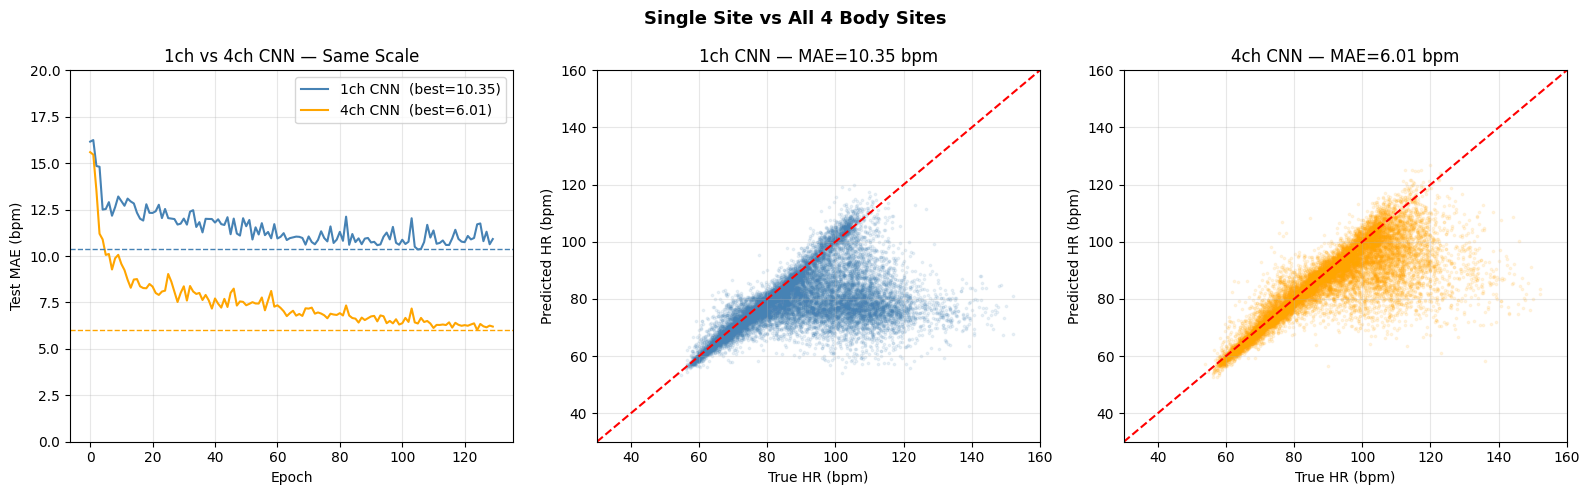

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── MAE curves ──
axes[0].plot(test_maes,      color='steelblue', linewidth=1.5,
             label=f'1ch CNN  (best={min(test_maes):.2f})')
axes[0].plot(test_maes_4ch2, color='orange',    linewidth=1.5,
             label=f'4ch CNN  (best={min(test_maes_4ch2):.2f})')
axes[0].axhline(min(test_maes),      color='steelblue', linestyle='--', linewidth=1)
axes[0].axhline(min(test_maes_4ch2), color='orange',    linestyle='--', linewidth=1)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test MAE (bpm)')
axes[0].set_title('1ch vs 4ch CNN — Same Scale')
axes[0].set_ylim(0, 20)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Scatter: 1ch CNN ──
axes[1].scatter(true, preds, alpha=0.1, s=3, color='steelblue')
axes[1].plot([30, 160], [30, 160], 'r--', linewidth=1.5)
axes[1].set_xlabel('True HR (bpm)')
axes[1].set_ylabel('Predicted HR (bpm)')
axes[1].set_title(f'1ch CNN — MAE={min(test_maes):.2f} bpm')
axes[1].set_xlim(30, 160)
axes[1].set_ylim(30, 160)
axes[1].grid(True, alpha=0.3)

# ── Scatter: 4ch CNN ──
axes[2].scatter(true_4ch, preds_4ch, alpha=0.1, s=3, color='orange')
axes[2].plot([30, 160], [30, 160], 'r--', linewidth=1.5)
axes[2].set_xlabel('True HR (bpm)')
axes[2].set_ylabel('Predicted HR (bpm)')
axes[2].set_title(f'4ch CNN — MAE={min(test_maes_4ch2):.2f} bpm')
axes[2].set_xlim(30, 160)
axes[2].set_ylim(30, 160)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Single Site vs All 4 Body Sites', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

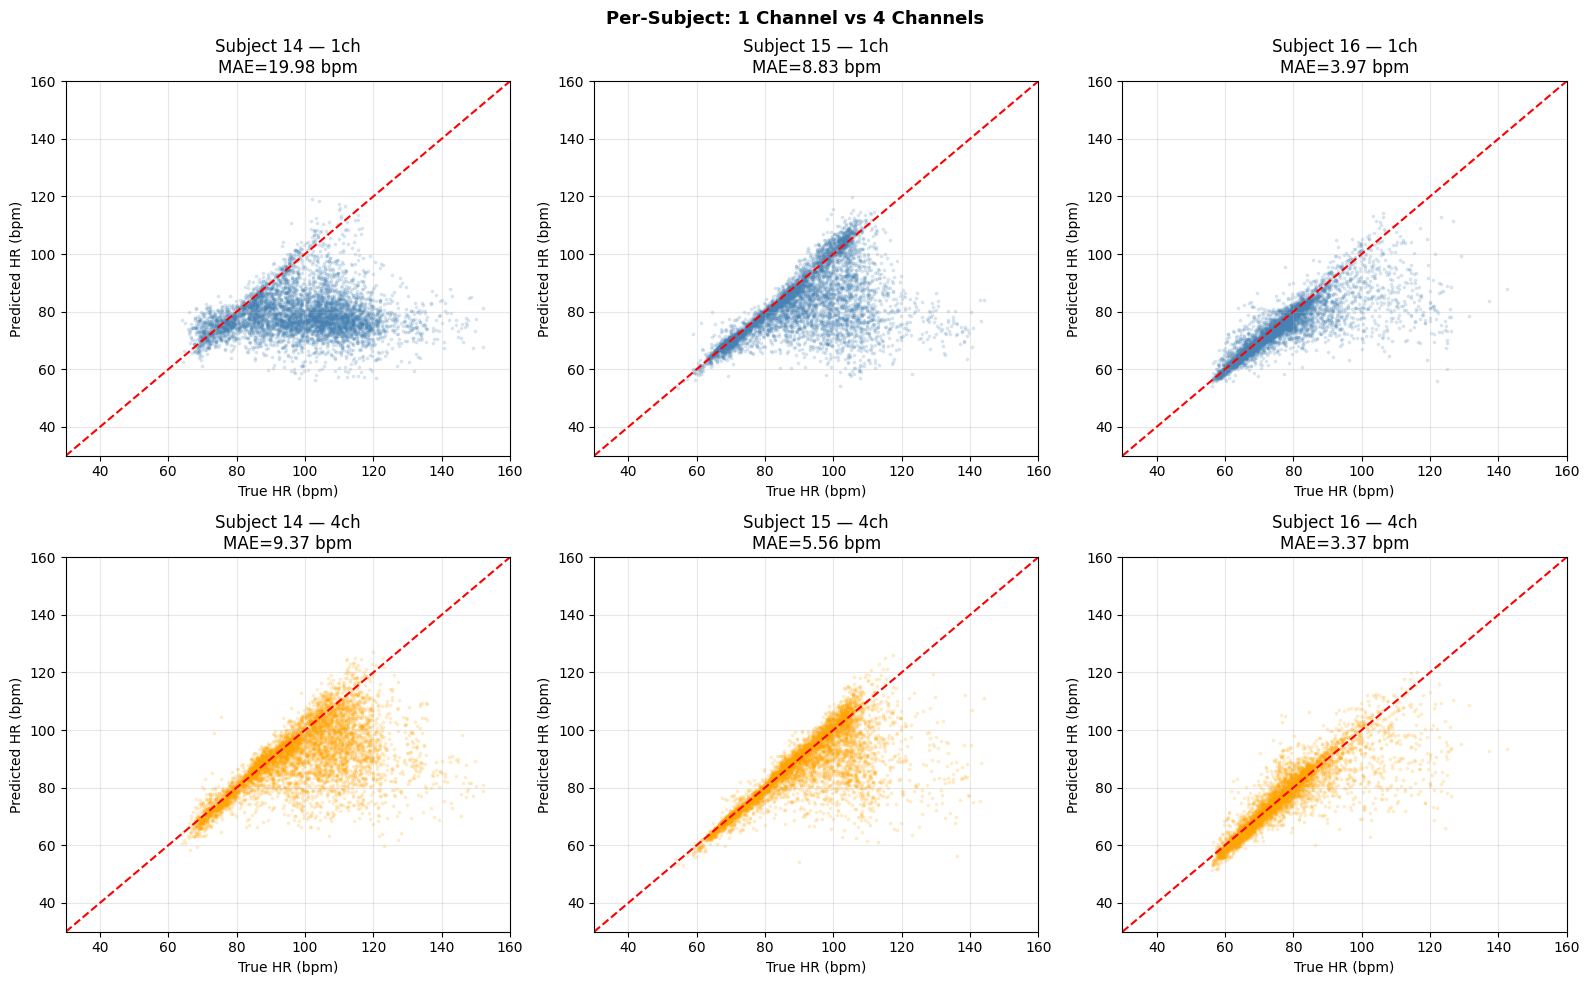

In [31]:
# Per-subject comparison: 1ch vs 4ch
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for plot_idx, subj_idx in enumerate([13, 14, 15]):
    
    # ── 1 channel ──
    ppg_i = mat['data_ppg_wrist'][subj_idx, 0]
    bpm_i = mat['data_bpm_values'][subj_idx, 0].flatten()
    mask  = (~np.isnan(ppg_i).any(axis=1) & ~np.isinf(ppg_i).any(axis=1) &
             (bpm_i >= 30) & ~np.isnan(bpm_i))
    
    X_1ch = torch.tensor(ppg_i[mask].astype(np.float32)).unsqueeze(1).to(device)
    y_sub = bpm_i[mask]
    
    model.eval()
    with torch.no_grad():
        preds_1ch = model(X_1ch).squeeze().cpu().numpy()
    mae_1ch = np.mean(np.abs(preds_1ch - y_sub))

    # ── 4 channels ──
    X_4ch_i, y_4ch_i = load_all_sites(mat, subj_idx)
    X_4ch_t = torch.tensor(X_4ch_i).to(device)

    model_4ch.eval()
    with torch.no_grad():
        preds_4ch_i = model_4ch(X_4ch_t).squeeze().cpu().numpy()
    mae_4ch = np.mean(np.abs(preds_4ch_i - y_4ch_i))

    # ── Plot 1ch ──
    axes[0, plot_idx].scatter(y_sub, preds_1ch, alpha=0.15, s=3, color='steelblue')
    axes[0, plot_idx].plot([30, 200], [30, 200], 'r--', linewidth=1.5)
    axes[0, plot_idx].set_title(f'Subject {subj_idx+1} — 1ch\nMAE={mae_1ch:.2f} bpm')
    axes[0, plot_idx].set_xlim(30, 160)
    axes[0, plot_idx].set_ylim(30, 160)
    axes[0, plot_idx].set_xlabel('True HR (bpm)')
    axes[0, plot_idx].set_ylabel('Predicted HR (bpm)')
    axes[0, plot_idx].grid(True, alpha=0.3)

    # ── Plot 4ch ──
    axes[1, plot_idx].scatter(y_4ch_i, preds_4ch_i, alpha=0.15, s=3, color='orange')
    axes[1, plot_idx].plot([30, 200], [30, 200], 'r--', linewidth=1.5)
    axes[1, plot_idx].set_title(f'Subject {subj_idx+1} — 4ch\nMAE={mae_4ch:.2f} bpm')
    axes[1, plot_idx].set_xlim(30, 160)
    axes[1, plot_idx].set_ylim(30, 160)
    axes[1, plot_idx].set_xlabel('True HR (bpm)')
    axes[1, plot_idx].set_ylabel('Predicted HR (bpm)')
    axes[1, plot_idx].grid(True, alpha=0.3)

plt.suptitle('Per-Subject: 1 Channel vs 4 Channels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# A regular CNN block vs a Residual block

# Regular CNN:
#   input → Conv → ReLU → output
#
# Residual block:
#   input → Conv → ReLU → Conv → + → output
#     └─────────────────────────┘
#   (the input is ADDED to the output — the "skip connection")
#
# Why does this help?
# If the conv layers learn nothing useful, the skip connection
# passes the input through unchanged — at worst it's a no-op.
# This makes deep networks much easier to train.

class ResBlock(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(channels)
        self.relu  = nn.ReLU()

    def forward(self, x):
        residual = x                        # save input
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + residual                # add input back
        return self.relu(out)

# Test the block
block = ResBlock(channels=32)
x_test = torch.randn(4, 32, 100)
out = block(x_test)
print(f"ResBlock input : {x_test.shape}")
print(f"ResBlock output: {out.shape}  (same shape — skip connection works)")
print()
print("The key idea: output = F(input) + input")
print("If F learns nothing → output = input (safe fallback)")
print("If F learns something useful → output = improvement over input")

ResBlock input : torch.Size([4, 32, 100])
ResBlock output: torch.Size([4, 32, 100])  (same shape — skip connection works)

The key idea: output = F(input) + input
If F learns nothing → output = input (safe fallback)
If F learns something useful → output = improvement over input


In [33]:
class ResNet1D(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        
        # Stem: project input to 32 filters
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )
        
        # Stack of residual blocks with increasing filters
        self.layer1 = nn.Sequential(ResBlock(32), ResBlock(32))
        self.down1  = nn.Conv1d(32, 64, kernel_size=1, stride=2)  # 200→100
        
        self.layer2 = nn.Sequential(ResBlock(64), ResBlock(64))
        self.down2  = nn.Conv1d(64, 128, kernel_size=1, stride=2) # 100→50
        
        self.layer3 = nn.Sequential(ResBlock(128), ResBlock(128))
        
        # Global average pool + predict
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        x = self.stem(x)
        x = self.down1(self.layer1(x))
        x = self.down2(self.layer2(x))
        x = self.layer3(x)
        x = self.pool(x)
        return self.head(x).squeeze(-1)

resnet = ResNet1D(in_channels=4).to(device)
print(f"ResNet parameters: {sum(p.numel() for p in resnet.parameters()):,}")
print(f"Simple CNN was:    18,545")
print()

# Trace shapes
x = torch.randn(4, 4, 200).to(device)
print(f"Input:   {x.shape}")
x = resnet.stem(x);   print(f"Stem:    {x.shape}")
x = resnet.layer1(x); print(f"Layer1:  {x.shape}")
x = resnet.down1(x);  print(f"Down1:   {x.shape}")
x = resnet.layer2(x); print(f"Layer2:  {x.shape}")
x = resnet.down2(x);  print(f"Down2:   {x.shape}")
x = resnet.layer3(x); print(f"Layer3:  {x.shape}")
x = resnet.pool(x);   print(f"Pool:    {x.shape}")

ResNet parameters: 624,545
Simple CNN was:    18,545

Input:   torch.Size([4, 4, 200])
Stem:    torch.Size([4, 32, 200])
Layer1:  torch.Size([4, 32, 200])
Down1:   torch.Size([4, 64, 100])
Layer2:  torch.Size([4, 64, 100])
Down2:   torch.Size([4, 128, 50])
Layer3:  torch.Size([4, 128, 50])
Pool:    torch.Size([4, 128, 1])


In [35]:
optimizer_res = torch.optim.Adam(resnet.parameters(), lr=1e-3)
scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer_res, T_max=130, eta_min=1e-5)

train_losses_res = []
test_maes_res    = []

for epoch in range(1, 131):
    # ── Train ──
    resnet.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader_4ch:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = resnet(X_batch)
        loss = criterion(pred, y_batch)
        optimizer_res.zero_grad()
        loss.backward()
        optimizer_res.step()
        epoch_loss += loss.item()
    scheduler.step()

    # ── Evaluate ──
    resnet.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader_4ch:
            pred = resnet(X_batch.to(device)).squeeze().cpu()
            all_preds.append(pred.numpy())
            all_true.append(y_batch.numpy())

    preds_res = np.concatenate(all_preds)
    true_res  = np.concatenate(all_true)
    mae       = np.mean(np.abs(preds_res - true_res))

    train_losses_res.append(epoch_loss / len(train_loader_4ch))
    test_maes_res.append(mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/130 | loss={train_losses_res[-1]:.3f} | test MAE={mae:.2f} bpm")

print(f"\nBest MAE: {min(test_maes_res):.2f} bpm at epoch {test_maes_res.index(min(test_maes_res))+1}")
print(f"4ch CNN was:  5.59 bpm")
print(f"1ch CNN was:  9.95 bpm")

Epoch  10/130 | loss=15.023 | test MAE=8.52 bpm
Epoch  20/130 | loss=10.275 | test MAE=6.89 bpm
Epoch  30/130 | loss=7.252 | test MAE=11.59 bpm
Epoch  40/130 | loss=5.826 | test MAE=8.80 bpm
Epoch  50/130 | loss=4.843 | test MAE=11.26 bpm
Epoch  60/130 | loss=4.184 | test MAE=11.32 bpm
Epoch  70/130 | loss=3.400 | test MAE=9.93 bpm
Epoch  80/130 | loss=2.983 | test MAE=9.37 bpm
Epoch  90/130 | loss=2.500 | test MAE=9.78 bpm
Epoch 100/130 | loss=2.175 | test MAE=11.20 bpm
Epoch 110/130 | loss=2.026 | test MAE=10.38 bpm
Epoch 120/130 | loss=1.909 | test MAE=10.30 bpm
Epoch 130/130 | loss=1.856 | test MAE=10.53 bpm

Best MAE: 3.52 bpm at epoch 16
4ch CNN was:  5.59 bpm
1ch CNN was:  9.95 bpm


In [36]:
# Retrain ResNet and save the best model
resnet2       = ResNet1D(in_channels=4).to(device)
optimizer_r2  = torch.optim.Adam(resnet2.parameters(), lr=1e-3)
scheduler_r2  = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer_r2, T_max=130, eta_min=1e-5)

best_mae      = float('inf')
best_weights  = None
train_losses_r2, test_maes_r2 = [], []

for epoch in range(1, 131):
    resnet2.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader_4ch:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = resnet2(X_batch)
        loss = criterion(pred, y_batch)
        optimizer_r2.zero_grad()
        loss.backward()
        optimizer_r2.step()
        epoch_loss += loss.item()
    scheduler_r2.step()

    resnet2.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader_4ch:
            pred = resnet2(X_batch.to(device)).squeeze().cpu()
            all_preds.append(pred.numpy())
            all_true.append(y_batch.numpy())

    preds_r2 = np.concatenate(all_preds)
    true_r2  = np.concatenate(all_true)
    mae      = np.mean(np.abs(preds_r2 - true_r2))

    train_losses_r2.append(epoch_loss / len(train_loader_4ch))
    test_maes_r2.append(mae)

    # Save best weights
    if mae < best_mae:
        best_mae     = mae
        best_weights = {k: v.clone() for k, v in resnet2.state_dict().items()}

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/130 | loss={train_losses_r2[-1]:.3f} | "
              f"test MAE={mae:.2f}  best={best_mae:.2f} bpm")

# Load best weights back
resnet2.load_state_dict(best_weights)
print(f"\nBest MAE: {best_mae:.2f} bpm")
print(f"4ch CNN was:  5.59 bpm")

Epoch  10/130 | loss=15.328 | test MAE=5.45  best=4.09 bpm
Epoch  20/130 | loss=13.170 | test MAE=3.22  best=3.07 bpm
Epoch  30/130 | loss=9.604 | test MAE=4.19  best=3.07 bpm
Epoch  40/130 | loss=7.341 | test MAE=4.00  best=3.07 bpm
Epoch  50/130 | loss=5.740 | test MAE=3.02  best=3.02 bpm
Epoch  60/130 | loss=4.541 | test MAE=3.83  best=3.02 bpm
Epoch  70/130 | loss=3.588 | test MAE=3.88  best=3.02 bpm
Epoch  80/130 | loss=2.701 | test MAE=3.67  best=3.02 bpm
Epoch  90/130 | loss=2.181 | test MAE=4.22  best=3.02 bpm
Epoch 100/130 | loss=1.828 | test MAE=3.55  best=3.02 bpm
Epoch 110/130 | loss=1.591 | test MAE=3.79  best=3.02 bpm
Epoch 120/130 | loss=1.477 | test MAE=3.83  best=3.02 bpm
Epoch 130/130 | loss=1.428 | test MAE=3.70  best=3.02 bpm

Best MAE: 3.02 bpm
4ch CNN was:  5.59 bpm


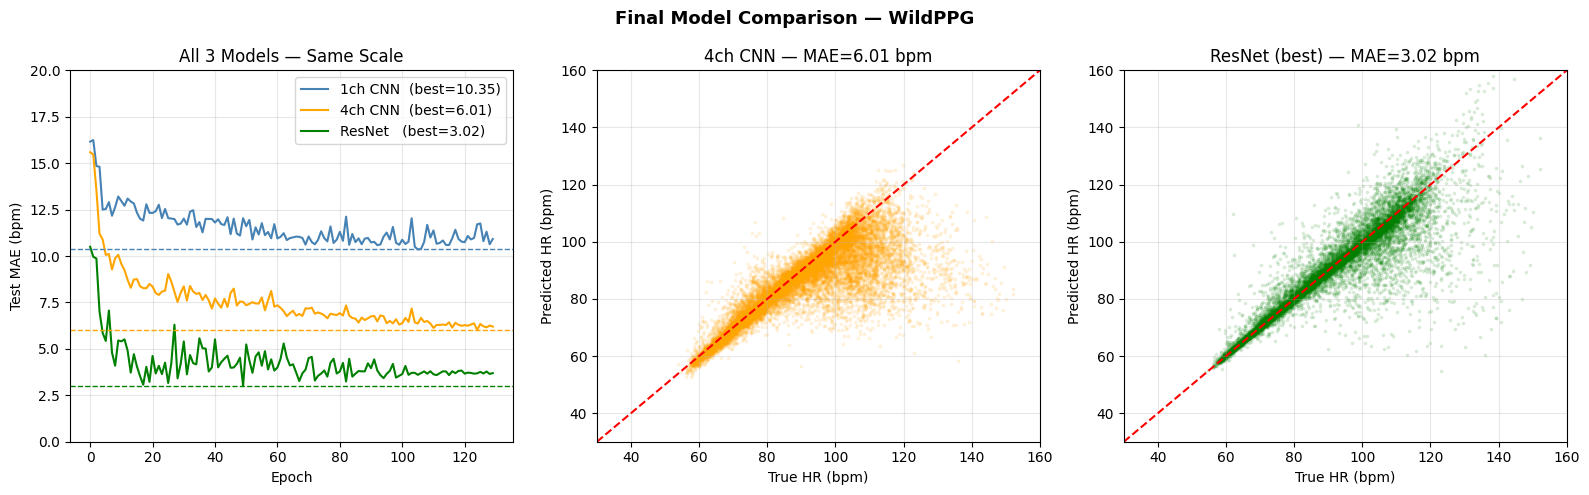

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── All 3 MAE curves on same scale ──
axes[0].plot(test_maes,      color='steelblue', linewidth=1.5,
             label=f'1ch CNN  (best={min(test_maes):.2f})')
axes[0].plot(test_maes_4ch2, color='orange',    linewidth=1.5,
             label=f'4ch CNN  (best={min(test_maes_4ch2):.2f})')
axes[0].plot(test_maes_r2,   color='green',     linewidth=1.5,
             label=f'ResNet   (best={best_mae:.2f})')
axes[0].axhline(min(test_maes),      color='steelblue', linestyle='--', linewidth=1)
axes[0].axhline(min(test_maes_4ch2), color='orange',    linestyle='--', linewidth=1)
axes[0].axhline(best_mae,            color='green',     linestyle='--', linewidth=1)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test MAE (bpm)')
axes[0].set_title('All 3 Models — Same Scale')
axes[0].set_ylim(0, 20)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Scatter: 4ch CNN ──
axes[1].scatter(true_4ch, preds_4ch, alpha=0.1, s=3, color='orange')
axes[1].plot([30, 160], [30, 160], 'r--', linewidth=1.5)
axes[1].set_xlabel('True HR (bpm)')
axes[1].set_ylabel('Predicted HR (bpm)')
axes[1].set_title(f'4ch CNN — MAE={min(test_maes_4ch2):.2f} bpm')
axes[1].set_xlim(30, 160)
axes[1].set_ylim(30, 160)
axes[1].grid(True, alpha=0.3)

# ── Scatter: ResNet ──
axes[2].scatter(true_best, preds_best, alpha=0.1, s=3, color='green')
axes[2].plot([30, 160], [30, 160], 'r--', linewidth=1.5)
axes[2].set_xlabel('True HR (bpm)')
axes[2].set_ylabel('Predicted HR (bpm)')
axes[2].set_title(f'ResNet (best) — MAE={best_mae:.2f} bpm')
axes[2].set_xlim(30, 160)
axes[2].set_ylim(30, 160)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Final Model Comparison — WildPPG', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

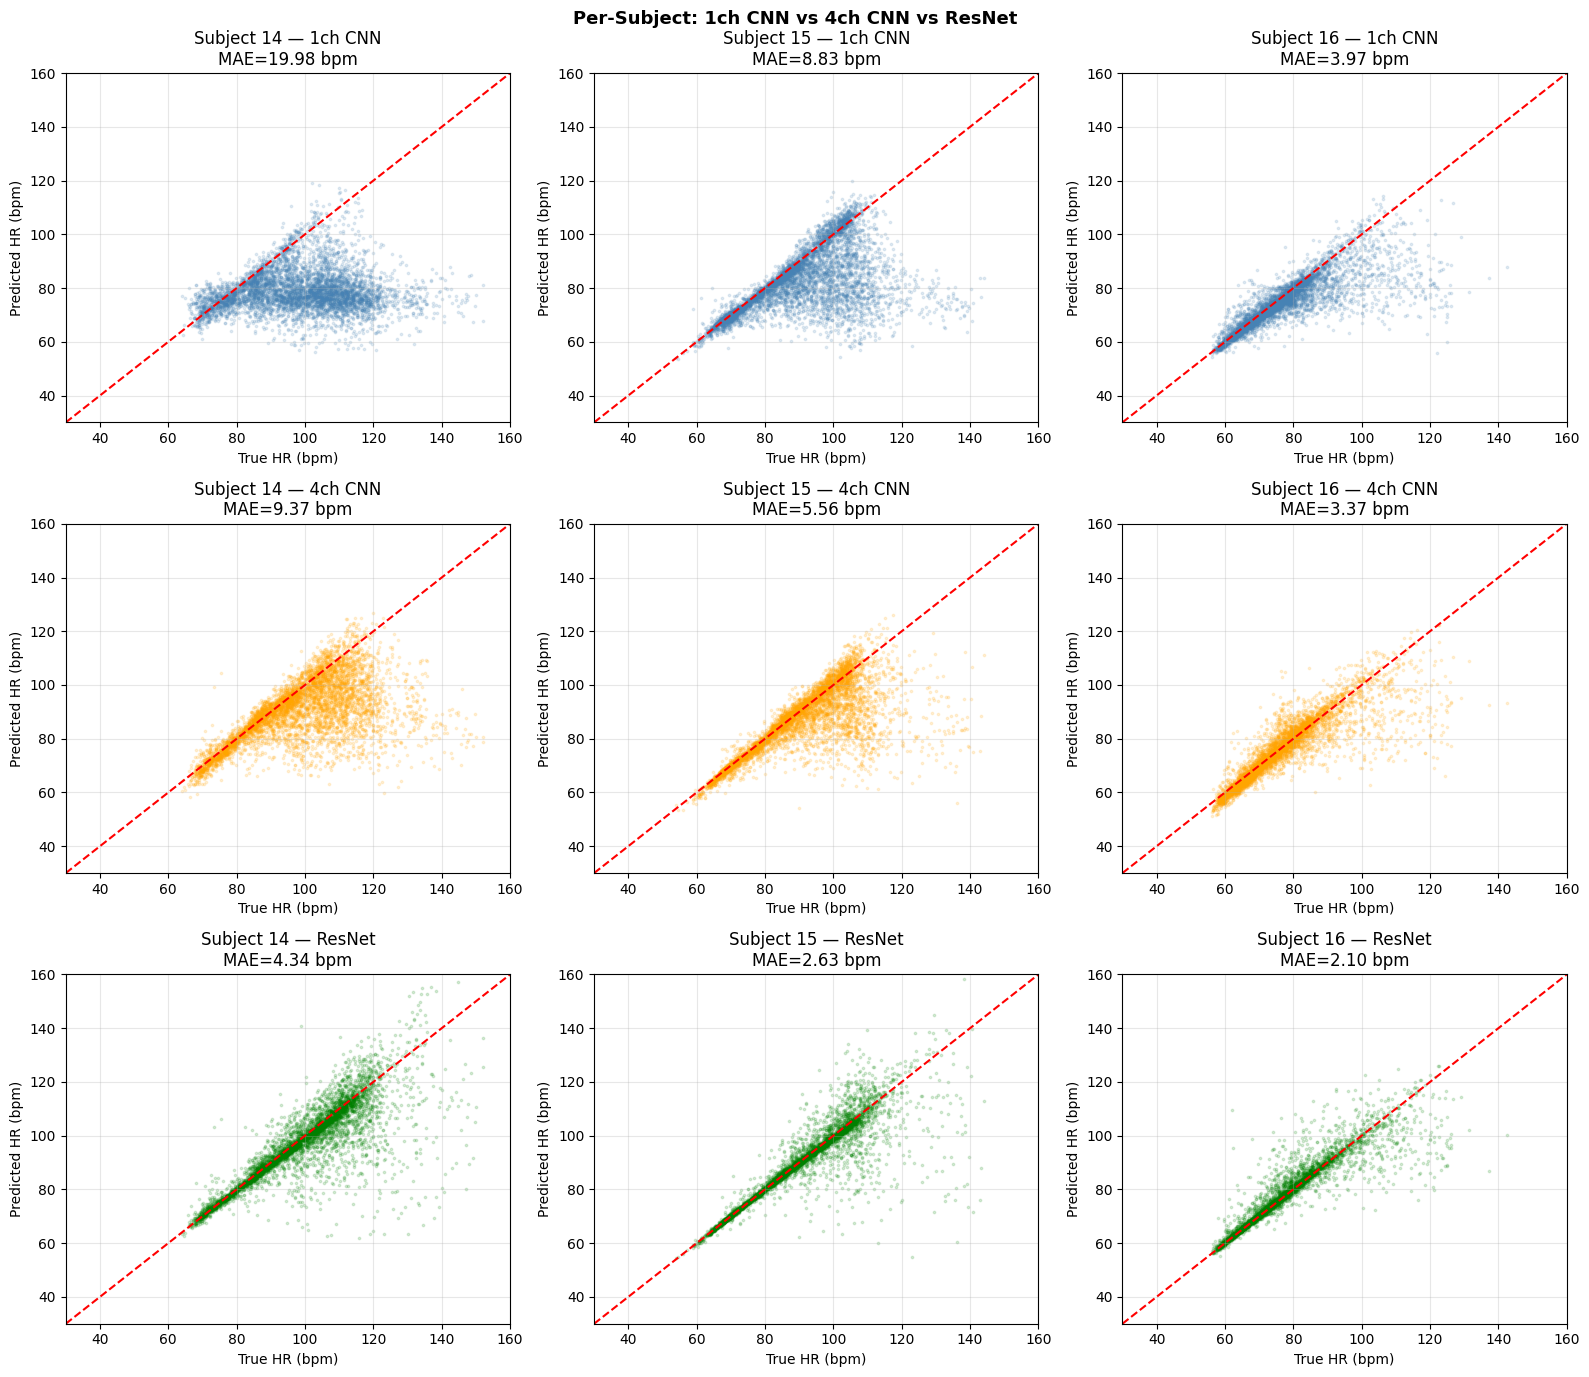

In [47]:
# Per-subject comparison: 1ch vs 4ch vs ResNet
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for plot_idx, subj_idx in enumerate([13, 14, 15]):

    # ── 1 channel ──
    ppg_i = mat['data_ppg_wrist'][subj_idx, 0]
    bpm_i = mat['data_bpm_values'][subj_idx, 0].flatten()
    mask  = (~np.isnan(ppg_i).any(axis=1) & ~np.isinf(ppg_i).any(axis=1) &
             (bpm_i >= 30) & ~np.isnan(bpm_i))
    X_1ch = torch.tensor(ppg_i[mask].astype(np.float32)).unsqueeze(1).to(device)
    y_sub = bpm_i[mask]
    model.eval()
    with torch.no_grad():
        preds_1ch = model(X_1ch).squeeze().cpu().numpy()
    mae_1ch = np.mean(np.abs(preds_1ch - y_sub))

    # ── 4 channels ──
    X_4ch_i, y_4ch_i = load_all_sites(mat, subj_idx)
    X_4ch_t = torch.tensor(X_4ch_i).to(device)
    model_4ch.eval()
    with torch.no_grad():
        preds_4ch_i = model_4ch(X_4ch_t).squeeze().cpu().numpy()
    mae_4ch = np.mean(np.abs(preds_4ch_i - y_4ch_i))

    # ── ResNet ──
    resnet2.eval()
    with torch.no_grad():
        preds_res_i = resnet2(X_4ch_t).squeeze().cpu().numpy()
    mae_res = np.mean(np.abs(preds_res_i - y_4ch_i))

    # ── Plot 1ch ──
    axes[0, plot_idx].scatter(y_sub, preds_1ch, alpha=0.15, s=3, color='steelblue')
    axes[0, plot_idx].plot([30, 160], [30, 160], 'r--', linewidth=1.5)
    axes[0, plot_idx].set_title(f'Subject {subj_idx+1} — 1ch CNN\nMAE={mae_1ch:.2f} bpm')
    axes[0, plot_idx].set_xlim(30, 160)
    axes[0, plot_idx].set_ylim(30, 160)
    axes[0, plot_idx].set_xlabel('True HR (bpm)')
    axes[0, plot_idx].set_ylabel('Predicted HR (bpm)')
    axes[0, plot_idx].grid(True, alpha=0.3)

    # ── Plot 4ch ──
    axes[1, plot_idx].scatter(y_4ch_i, preds_4ch_i, alpha=0.15, s=3, color='orange')
    axes[1, plot_idx].plot([30, 160], [30, 160], 'r--', linewidth=1.5)
    axes[1, plot_idx].set_title(f'Subject {subj_idx+1} — 4ch CNN\nMAE={mae_4ch:.2f} bpm')
    axes[1, plot_idx].set_xlim(30, 160)
    axes[1, plot_idx].set_ylim(30, 160)
    axes[1, plot_idx].set_xlabel('True HR (bpm)')
    axes[1, plot_idx].set_ylabel('Predicted HR (bpm)')
    axes[1, plot_idx].grid(True, alpha=0.3)

    # ── Plot ResNet ──
    axes[2, plot_idx].scatter(y_4ch_i, preds_res_i, alpha=0.15, s=3, color='green')
    axes[2, plot_idx].plot([30, 160], [30, 160], 'r--', linewidth=1.5)
    axes[2, plot_idx].set_title(f'Subject {subj_idx+1} — ResNet\nMAE={mae_res:.2f} bpm')
    axes[2, plot_idx].set_xlim(30, 160)
    axes[2, plot_idx].set_ylim(30, 160)
    axes[2, plot_idx].set_xlabel('True HR (bpm)')
    axes[2, plot_idx].set_ylabel('Predicted HR (bpm)')
    axes[2, plot_idx].grid(True, alpha=0.3)

plt.suptitle('Per-Subject: 1ch CNN vs 4ch CNN vs ResNet', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()